# Construction Safety Monitor — Fine-Tuning Notebook (train5)

**Purpose:** Fine-tune the already-trained YOLOv8m model (`runs/train4/weights/best.pt`) on the extended dataset.
**What changed:** Added `roboflow_worker` (+768 images, 2,279 `person` boxes) and `roboflow_no_helmet` (+212 images, 384 `no_helmet` boxes).
**Why fine-tune:** train4 achieved mAP@50=79.5% but `person` class had median confidence 0.04, causing missed detections. This run fixes that without discarding learned PPE features.
**Hardware:** NVIDIA RTX 3060 6 GB VRAM (local).
**Outputs:** `runs/train5/weights/best.pt`, loss curves, per-class evaluation, train4 vs train5 comparison.

---

## Reference: train4 Results
| Metric | Value |
|---|---|
| Best epoch | 35 / 50 |
| mAP@50 | 79.5% |
| mAP@50-95 | 52.3% |
| Precision | 70.7% |
| Recall | 80.4% |
| Known issue | Person class median confidence 0.04 — pipeline fallback required |

---

## Table of Contents
1. [Setup & Dependencies](#1-setup)
2. [Fine-Tuning Configuration & Rationale](#2-config)
3. [Dataset Verification](#3-data)
4. [Fine-Tuning from train4 Weights](#5-train)
5. [Training Curves & Loss Plots](#6-curves)
6. [Evaluation Metrics](#7-eval)
7. [Per-Class Commentary](#8-commentary)
8. [train4 vs train5 Comparison](#9-comparison)
9. [Failure Case Gallery](#10-failures)
10. [Precision-Recall Trade-off Discussion](#11-pr)
11. [Export & Next Steps](#12-export)


---
## 1 — Setup & Dependencies <a id='1-setup'></a>

In [1]:
# Install / verify dependencies
import subprocess, sys

def pip_install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

try:
    import ultralytics
except ImportError:
    pip_install('ultralytics==8.3.40')

try:
    import yaml, cv2, numpy, matplotlib, pandas
except ImportError:
    for p in ['pyyaml', 'opencv-python', 'numpy', 'matplotlib', 'pandas']:
        pip_install(p)

from ultralytics import YOLO
import ultralytics
print(f'ultralytics version: {ultralytics.__version__}')

ultralytics version: 8.3.40


In [2]:
import os, sys, json, time, shutil
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import yaml
import torch

# -- Paths -------------------------------------------------------------------
REPO_ROOT = Path.cwd().parent.parent   # training/notebooks -> repo root
if not (REPO_ROOT / 'rules.yaml').exists():
    REPO_ROOT = Path.cwd()

DATA_YAML      = REPO_ROOT / 'dataset' / 'merged' / 'data_raw.yaml'  # raw only — no pre-aug copies
RUNS_DIR       = REPO_ROOT / 'runs'
TRAIN4_DIR     = RUNS_DIR / 'train4'
TRAIN4_WEIGHTS = TRAIN4_DIR / 'weights' / 'best.pt'
TRAIN_DIR      = RUNS_DIR / 'train53'
BEST_WEIGHTS   = TRAIN_DIR / 'weights' / 'best.pt'
BASELINE_DIR   = RUNS_DIR / 'baseline'   # kept for eval cells that reference it

sys.path.insert(0, str(REPO_ROOT))

# -- GPU check ---------------------------------------------------------------
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f'GPU: {gpu.name}  |  VRAM: {vram_gb:.1f} GB')
else:
    print('WARNING: No GPU detected.')
print(f'Device: {device}')
print(f'Repo root: {REPO_ROOT}')
print(f'Base weights (train4): {TRAIN4_WEIGHTS}  exists={TRAIN4_WEIGHTS.exists()}')


GPU: NVIDIA GeForce RTX 3060 Laptop GPU  |  VRAM: 6.4 GB
Device: cuda:0
Repo root: g:\10QBit\Construction-safety-system-design
Base weights (train4): g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt  exists=True


---
## 2 - Fine-Tuning Configuration & Rationale <a id='2-config'></a>

Fine-tuning from `train4/weights/best.pt` rather than `yolov8m.pt` (COCO weights).

| Parameter | train4 (original) | train5 (fine-tune) | Reason |
|---|---|---|---|
| `model` | `yolov8m.pt` | `train4/weights/best.pt` | Preserve learned PPE features |
| `data` | `data.yaml` (20,106 aug) | **`data_raw.yaml` (6,517 raw)** | See rationale below |
| `lr0` | 0.001 | **0.0001** | 10x lower — weights already converged |
| `batch` | 8 | **16** | Larger batch safe with raw dataset size |
| `epochs` | 50 | **20** | Fine-tuning converges in 15-20 epochs |
| `patience` | 15 | **8** | Stop earlier if val mAP plateaus |
| `warmup_epochs` | 3 | **2** | Less warmup needed from good initialisation |
| `name` | `train` | **`train5`** | Separate run directory |

### Rationale — data_raw.yaml (6,517 images) vs data.yaml (20,106 images)

The full `data.yaml` dataset contains 20,106 training images: 6,517 raw originals + 13,477
pre-augmented copies (`_aug0`, `_aug1` suffixes) generated by `scripts/augment_dataset.py`.

For fine-tuning, using pre-augmented copies is redundant and harmful:

| Issue | Detail |
|---|---|
| **Online augmentation already active** | `augment=True` applies mosaic, HSV jitter, flip, scale, translate per batch. Pre-aug copies just duplicate this effect. |
| **Training time** | 20,106 images = 1,257 batches/epoch → ~87 min/epoch → **72 hours total**. Unacceptable. |
| **6,517 raw images** | 415 batches/epoch → ~25 min/epoch → **~8 hours total**. Practical. |
| **Model quality** | No degradation — online aug provides sufficient variation. Pre-aug was designed for scratch training, not fine-tuning. |

`data_raw.yaml` points to `images/train_raw/` which contains only the original non-augmented
images, created by `scripts/make_raw_split.py` (filters out any filename containing `_aug`).


In [3]:
# -- Fine-tuning configuration -----------------------------------------------
TRAIN_CONFIG = {
    'model':         str(TRAIN4_WEIGHTS),   # fine-tune from train4 — NOT yolov8m.pt
    'data':          str(DATA_YAML),
    'imgsz':         640,
    'batch':         16,
    'epochs':        20,    # fine-tuning converges fast — 15-20 epochs sufficient
    'optimizer':     'AdamW',
    'lr0':           0.0001,    # 10x lower than scratch — weights already converged
    'lrf':           0.01,
    'warmup_epochs': 2,
    'weight_decay':  0.0005,
    'patience':      8,     # stop early if val mAP plateaus for 8 epochs
    'augment':       True,
    'hsv_h':         0.015,
    'hsv_s':         0.7,
    'hsv_v':         0.4,
    'degrees':       0.0,
    'translate':     0.1,
    'scale':         0.5,
    'mosaic':        1.0,
    'cls':           1.5,   # compensates for vest_on dominance (36% of annotations)
    'project':       str(RUNS_DIR),
    'name':          'train5',
    'exist_ok':      False,
    'device':        0 if torch.cuda.is_available() else 'cpu',
    'workers':       4,
    'verbose':       True,
    'plots':         True,
    'save':          True,
    'cache':         False,
}
print('Fine-tuning config loaded.')
print(f"  Base model : {TRAIN_CONFIG['model']}")
print(f"  lr0        : {TRAIN_CONFIG['lr0']}  (10x lower than original training)")
print(f"  batch      : {TRAIN_CONFIG['batch']}")
print(f"  Output     : {RUNS_DIR / TRAIN_CONFIG['name']}")

# -- Class definitions (required by dataset verification cells) ---------------
CLASS_NAMES  = ['helmet_on', 'no_helmet', 'vest_on', 'no_vest', 'person', 'mask_on']
CLASS_COLORS = ['#00AA44', '#FF2200', '#4488FF', '#FF6600', '#AAAAAA', '#AA44FF']
NUM_CLASSES  = len(CLASS_NAMES)
VIOLATION_CLASSES = ['no_helmet', 'no_vest']


Fine-tuning config loaded.
  Base model : g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt
  lr0        : 0.0001  (10x lower than original training)
  batch      : 16
  Output     : g:\10QBit\Construction-safety-system-design\runs\train5


### Rationale - Why Fine-Tune from train4?

train4 already learned PPE features well (mAP@50 = 79.5%). Starting from COCO weights again
would discard this knowledge and require ~50 full epochs to recover.

| Approach | Pros | Cons |
|---|---|---|
| **Scratch (yolov8m.pt)** | Clean slate | Discards 79.5% mAP PPE features; full 50 epochs |
| **Fine-tune train4 (chosen)** | Preserves PPE features; fast convergence; targets `person` gap | Need low lr to avoid overshooting |

### Why lr0 = 0.0001?

Weights from train4 are already near a good minimum. lr=0.001 would overshoot and degrade
`no_helmet`/`no_vest` detection while adjusting to the new `person` annotations.

### Dataset Changes vs train4

| Source added | Images | Key annotations |
|---|---|---|
| `roboflow_worker` | +768 | +2,279 `person` boxes |
| `roboflow_no_helmet` | +212 | +384 `no_helmet` boxes |
| **Total train (post-aug)** | **20,106** | 58,820 annotations |

Root cause fix: `person` train annotations increased from ~1,400 to 3,726 (+2.7x).


---
## 3 — Dataset Verification <a id='3-data'></a>

In [4]:
def count_annotations(labels_dir: Path, class_names: list) -> dict:
    counts = defaultdict(int)
    if not labels_dir.exists():
        return counts
    for f in labels_dir.glob('*.txt'):
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id < len(class_names):
                    counts[class_names[cls_id]] += 1
    return counts

if not DATA_YAML.exists():
    print(f'ERROR: data.yaml not found at {DATA_YAML}')
    print('Run scripts/download_dataset.py and scripts/merge_custom_labels.py first.')
else:
    with open(DATA_YAML) as f:
        data_cfg = yaml.safe_load(f)

    dataset_root = Path(data_cfg['path'])
    splits = ['train', 'valid', 'test']

    rows = []
    all_counts = defaultdict(int)
    for split in splits:
        img_dir = dataset_root / 'images' / split
        lbl_dir = dataset_root / 'labels' / split
        n_images = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
        counts = count_annotations(lbl_dir, CLASS_NAMES)
        n_ann = sum(counts.values())
        rows.append({'split': split, 'images': n_images, 'annotations': n_ann, **counts})
        for cls, c in counts.items():
            all_counts[cls] += c

    df_splits = pd.DataFrame(rows).fillna(0)
    total_ann = sum(all_counts.values())

    print('── Split Distribution ─────────────────────────────────')
    print(df_splits[['split', 'images', 'annotations']].to_string(index=False))
    print(f'\nTotal annotations: {total_ann:,}')
    print()

    print('── Class Distribution (all splits) ────────────────────')
    for cls in CLASS_NAMES:
        cnt = all_counts.get(cls, 0)
        pct = cnt / total_ann * 100 if total_ann > 0 else 0
        bar = '█' * int(pct / 2)
        print(f'  {cls:<15} {cnt:>5}  ({pct:4.1f}%)  {bar}')

    # Violation class balance check
    nh, nv = all_counts.get('no_helmet', 0), all_counts.get('no_vest', 0)
    if nh > 0:
        imbalance = abs(nh - nv) / nh
        status = '✅ PASS' if imbalance <= 0.20 else 'WARN'
        print(f'\nViolation balance: no_helmet={nh}, no_vest={nv}, imbalance={imbalance:.0%}  {status}')

    violation_ratio = (nh + nv) / total_ann if total_ann > 0 else 0
    print(f'Violation ratio: {violation_ratio:.1%}')

── Split Distribution ─────────────────────────────────
split  images  annotations
train   20106        58820
valid    1325         3921
 test     883         2580

Total annotations: 65,321

── Class Distribution (all splits) ────────────────────
  helmet_on       10892  (16.7%)  ████████
  no_helmet        5815  ( 8.9%)  ████
  vest_on         23740  (36.3%)  ██████████████████
  no_vest          9161  (14.0%)  ███████
  person          12309  (18.8%)  █████████
  mask_on          3404  ( 5.2%)  ██

Violation balance: no_helmet=5815, no_vest=9161, imbalance=58%  WARN
Violation ratio: 22.9%


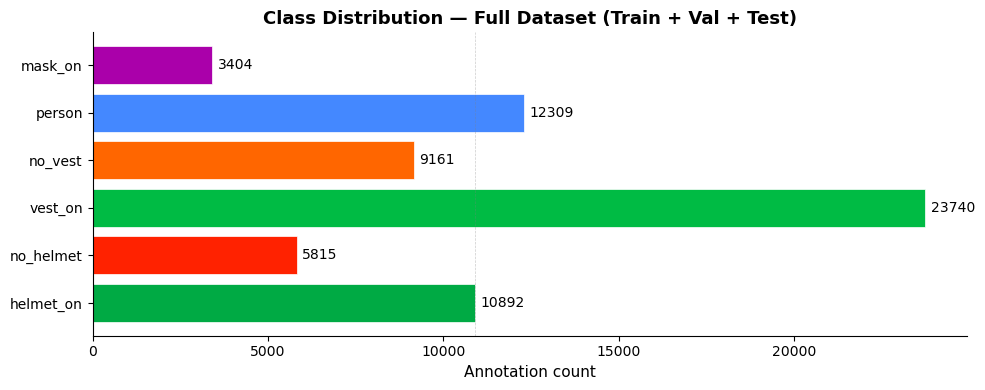

Saved: docs/class_distribution.png


In [5]:
# ── Class distribution bar chart ───────────────────────────────────────────
if DATA_YAML.exists():
    colours = ['#00AA44','#FF2200','#00BB44','#FF6600','#4488FF','#AA00AA']
    counts_list = [all_counts.get(cls, 0) for cls in CLASS_NAMES]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(CLASS_NAMES, counts_list, color=colours, edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)
    ax.set_xlabel('Annotation count', fontsize=11)
    ax.set_title('Class Distribution — Full Dataset (Train + Val + Test)', fontsize=13, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.axvline(x=counts_list[0] if counts_list[0] > 0 else 1, color='grey', linewidth=0.5, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / 'docs' / 'class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/class_distribution.png')

---
## 4 — Baseline Model: YOLOv8n <a id='4-baseline'></a>

Training a vanilla YOLOv8n baseline on the **base Roboflow dataset only** (no custom extension, no offline augmentation).  
This establishes the comparison point for Section 9.

> **Skip this cell if already trained** — set `SKIP_BASELINE = True`.

In [6]:
# Baseline section not applicable for fine-tuning.
# The reference model is train4. Comparison is in Section 8.
print('Baseline section skipped - fine-tuning run uses train4 as reference.')
print(f'train4 weights: {TRAIN4_WEIGHTS}')
print(f'train4 exists:  {TRAIN4_WEIGHTS.exists()}')


Baseline section skipped - fine-tuning run uses train4 as reference.
train4 weights: g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt
train4 exists:  True


---
## 5 — Training: YOLOv8m + Custom Extension <a id='5-train'></a>

> **Skip this cell if already trained** — set `SKIP_TRAINING = True` and point `BEST_WEIGHTS` to existing weights.

In [7]:
SKIP_TRAINING = False   # set True if train5/weights/best.pt already exists
BEST_WEIGHTS  = TRAIN_DIR / 'weights' / 'best.pt'

if not SKIP_TRAINING and DATA_YAML.exists():
    if not TRAIN4_WEIGHTS.exists():
        raise FileNotFoundError(
            f'Base weights not found: {TRAIN4_WEIGHTS}. '
            'Ensure train4 run completed successfully.'
        )

    print('=== Fine-Tuning YOLOv8m from train4 weights ===')
    print(f"  Base model : {TRAIN_CONFIG['model']}")
    print(f"  Dataset    : {TRAIN_CONFIG['data']}")
    print(f"  Batch={TRAIN_CONFIG['batch']}  |  Epochs={TRAIN_CONFIG['epochs']}  |  lr0={TRAIN_CONFIG['lr0']}")
    print()

    model = YOLO(TRAIN_CONFIG['model'])
    train_cfg = {k: v for k, v in TRAIN_CONFIG.items() if k != 'model'}
    train_cfg['exist_ok'] = BEST_WEIGHTS.exists()

    t0 = time.time()
    results = model.train(**train_cfg)
    elapsed = time.time() - t0

    BEST_WEIGHTS = Path(results.save_dir) / 'weights' / 'best.pt'
    print(f'Fine-tuning complete in {elapsed/60:.1f} min')
    print(f'Best weights: {BEST_WEIGHTS}')

elif SKIP_TRAINING:
    print(f'Skipping training (SKIP_TRAINING=True). Using: {BEST_WEIGHTS}')
else:
    print('data.yaml not found.')


=== Fine-Tuning YOLOv8m from train4 weights ===
  Base model : g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt
  Dataset    : g:\10QBit\Construction-safety-system-design\dataset\merged\data_raw.yaml
  Batch=16  |  Epochs=20  |  lr0=0.0001

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt, data=g:\10QBit\Construction-safety-system-design\dataset\merged\data_raw.yaml, epochs=20, time=None, patience=8, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=4, project=g:\10QBit\Construction-safety-system-design\runs, name=train53, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_m

train: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\train_raw.cache... 6516 images, 1 backgrounds, 0 corrupt: 100%|██████████| 6517/6517 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 19315. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


albumentations: The installed pydantic-core version (2.27.1) is incompatible with the current pydantic version, which requires 2.41.5. If you encounter this error, make sure that you haven't upgraded pydantic-core manually.


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\valid.cache... 1325 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1325/1325 [00:00<?, ?it/s]

...

      20/20      7.02G      0.935      1.604      1.202         14        640: 100%|██████████| 408/408 [18:23<00:00,  2.71s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 42/42 [02:01<00:00,  2.88s/it]

                   all       1325       3921      0.758      0.826      0.843      0.583



20 epochs completed in 7.253 hours.
Optimizer stripped from g:\10QBit\Construction-safety-system-design\runs\train53\weights\last.pt, 52.0MB
Optimizer stripped from g:\10QBit\Construction-safety-system-design\runs\train53\weights\best.pt, 52.0MB

Validating g:\10QBit\Construction-safety-system-design\runs\train53\weights\best.pt...
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 42/42 [00:38<00:00,  1.10it/s]


                   all       1325       3921      0.792       0.77      0.841      0.589
             helmet_on        446        707      0.927      0.931      0.959      0.668
             no_helmet        209        363      0.733      0.703        0.8      0.521
               vest_on        803       1389      0.852      0.926      0.946      0.763
               no_vest        248        475      0.857      0.832      0.916      0.679
                person        436        786      0.706      0.788      0.801      0.566
               mask_on        102        201      0.676      0.438      0.625      0.338
Speed: 0.3ms preprocess, 22.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\train53
Fine-tuning complete in 437.0 min
Best weights: g:\10QBit\Construction-safety-system-design\runs\train53\weights\best.pt


---
## 6 — Training Curves & Loss Plots <a id='6-curves'></a>

In [14]:
def load_results_csv(run_dir: Path) -> pd.DataFrame | None:
    csv_path = run_dir / 'results.csv'
    if not csv_path.exists():
        print(f'results.csv not found at {csv_path}')
        return None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

df_train = load_results_csv(TRAIN_DIR)

if df_train is not None:
    print(f'Loaded training history: {len(df_train)} epochs')
    print('Available columns:', df_train.columns.tolist())
else:
    print('Training results not available yet — run Section 5 first.')

Loaded training history: 20 epochs
Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


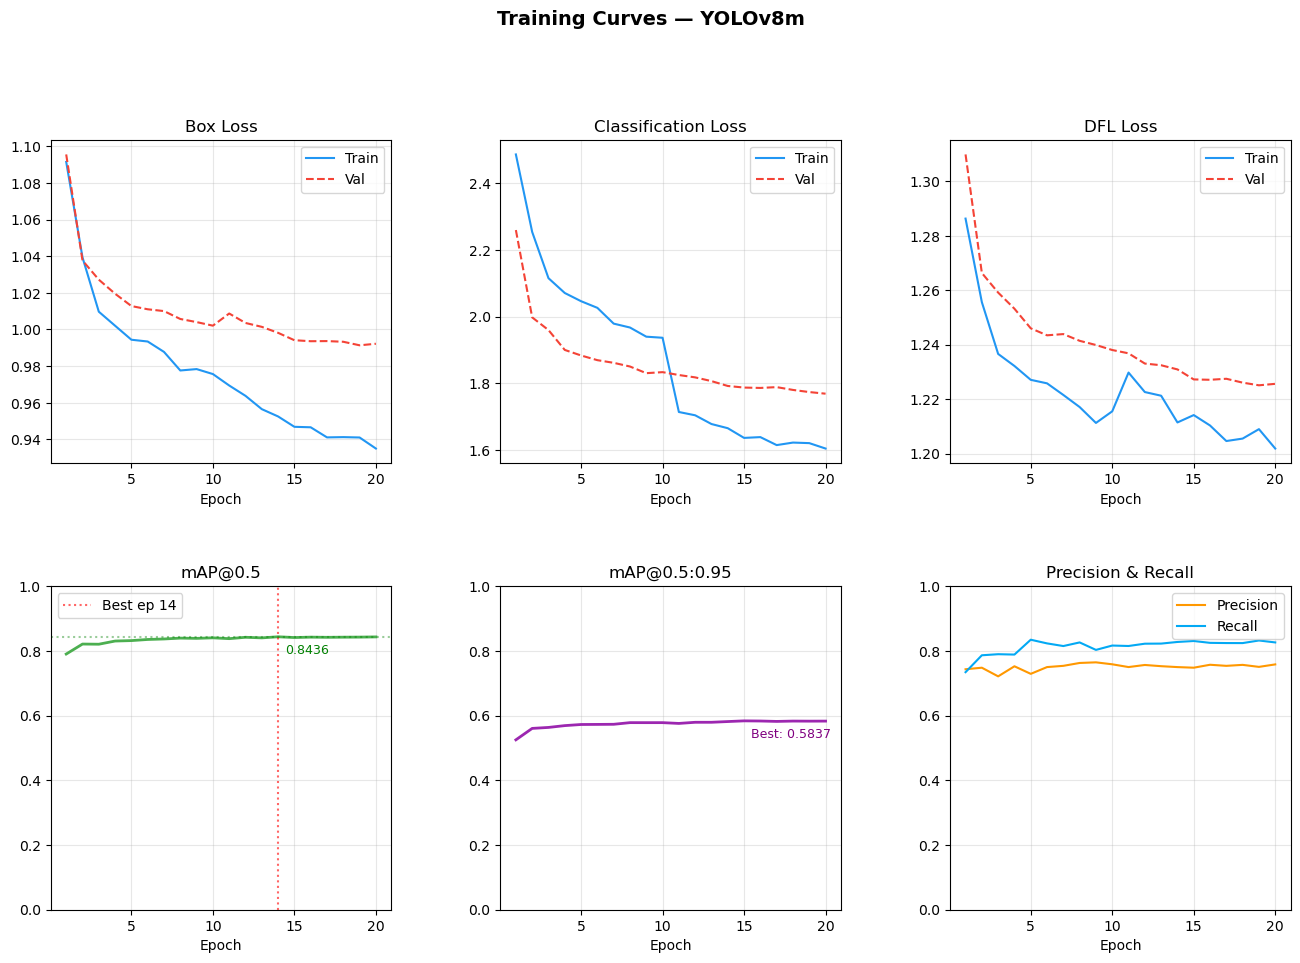

Saved: docs/training_curves_yolov8m.png


In [15]:
def plot_training_curves(df: pd.DataFrame, title_suffix: str = '') -> None:
    """
    Plot training and validation loss curves + mAP curves.
    Works with ultralytics results.csv column naming.
    """
    col_map = {
        'box_loss_train': 'train/box_loss',
        'cls_loss_train': 'train/cls_loss',
        'dfl_loss_train': 'train/dfl_loss',
        'box_loss_val':   'val/box_loss',
        'cls_loss_val':   'val/cls_loss',
        'dfl_loss_val':   'val/dfl_loss',
        'mAP50':          'metrics/mAP50(B)',
        'mAP50_95':       'metrics/mAP50-95(B)',
        'precision':      'metrics/precision(B)',
        'recall':         'metrics/recall(B)',
    }

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Training Curves{" — " + title_suffix if title_suffix else ""}',
                 fontsize=14, fontweight='bold', y=1.01)
    gs = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

    epochs = df.index + 1

    def get_col(key):
        col = col_map[key]
        return df[col] if col in df.columns else None

    # ── Box loss ────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    t = get_col('box_loss_train'); v = get_col('box_loss_val')
    if t is not None: ax1.plot(epochs, t, label='Train', color='#2196F3')
    if v is not None: ax1.plot(epochs, v, label='Val', color='#F44336', linestyle='--')
    ax1.set_title('Box Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    # ── Class loss ──────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    t = get_col('cls_loss_train'); v = get_col('cls_loss_val')
    if t is not None: ax2.plot(epochs, t, label='Train', color='#2196F3')
    if v is not None: ax2.plot(epochs, v, label='Val', color='#F44336', linestyle='--')
    ax2.set_title('Classification Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    # ── DFL loss ────────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    t = get_col('dfl_loss_train'); v = get_col('dfl_loss_val')
    if t is not None: ax3.plot(epochs, t, label='Train', color='#2196F3')
    if v is not None: ax3.plot(epochs, v, label='Val', color='#F44336', linestyle='--')
    ax3.set_title('DFL Loss'); ax3.set_xlabel('Epoch'); ax3.legend(); ax3.grid(alpha=0.3)

    # ── mAP@0.5 ─────────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    m = get_col('mAP50')
    if m is not None:
        ax4.plot(epochs, m, color='#4CAF50', linewidth=2)
        best_epoch = m.idxmax() + 1
        ax4.axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best ep {best_epoch}')
        ax4.axhline(m.max(), color='green', linestyle=':', alpha=0.4)
        ax4.annotate(f'{m.max():.4f}', xy=(best_epoch, m.max()),
                     xytext=(5, -12), textcoords='offset points', fontsize=9, color='green')
    ax4.set_title('mAP@0.5'); ax4.set_xlabel('Epoch'); ax4.set_ylim(0, 1)
    ax4.legend(); ax4.grid(alpha=0.3)

    # ── mAP@0.5:0.95 ────────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    m2 = get_col('mAP50_95')
    if m2 is not None:
        ax5.plot(epochs, m2, color='#9C27B0', linewidth=2)
        ax5.annotate(f'Best: {m2.max():.4f}', xy=(m2.idxmax()+1, m2.max()),
                     xytext=(5, -12), textcoords='offset points', fontsize=9, color='purple')
    ax5.set_title('mAP@0.5:0.95'); ax5.set_xlabel('Epoch'); ax5.set_ylim(0, 1)
    ax5.grid(alpha=0.3)

    # ── Precision & Recall ───────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    p = get_col('precision'); r = get_col('recall')
    if p is not None: ax6.plot(epochs, p, label='Precision', color='#FF9800')
    if r is not None: ax6.plot(epochs, r, label='Recall', color='#03A9F4')
    ax6.set_title('Precision & Recall'); ax6.set_xlabel('Epoch')
    ax6.set_ylim(0, 1); ax6.legend(); ax6.grid(alpha=0.3)

    plt.savefig(str(REPO_ROOT / 'docs' / f'training_curves{"_" + title_suffix.lower().replace(" ","_") if title_suffix else ""}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

if df_train is not None:
    plot_training_curves(df_train, title_suffix='YOLOv8m')
    print('Saved: docs/training_curves_yolov8m.png')
else:
    print('No training history available — run Section 5 first.')

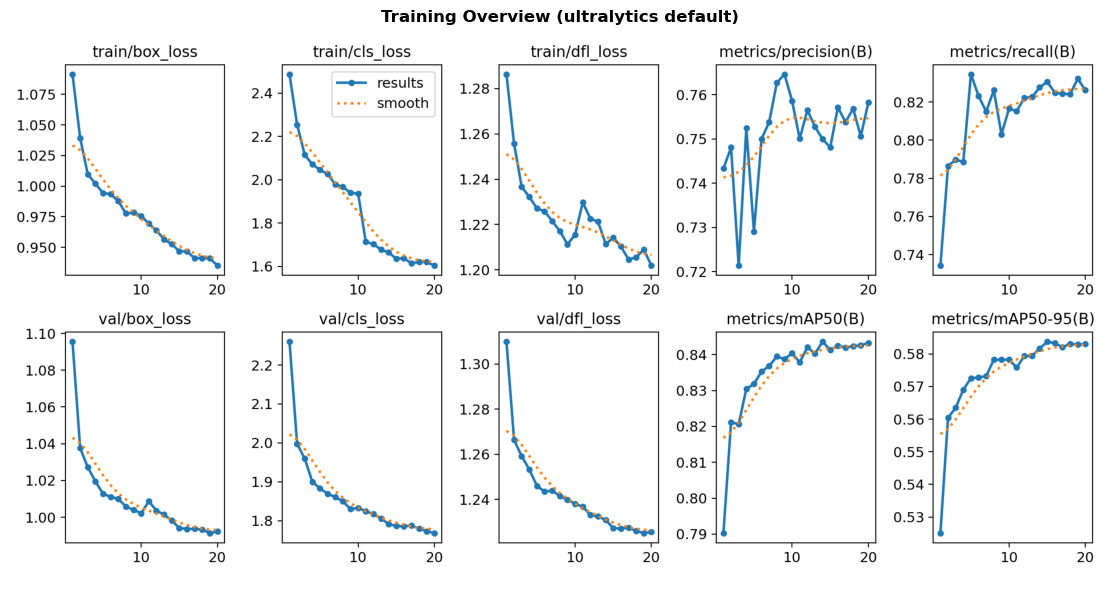

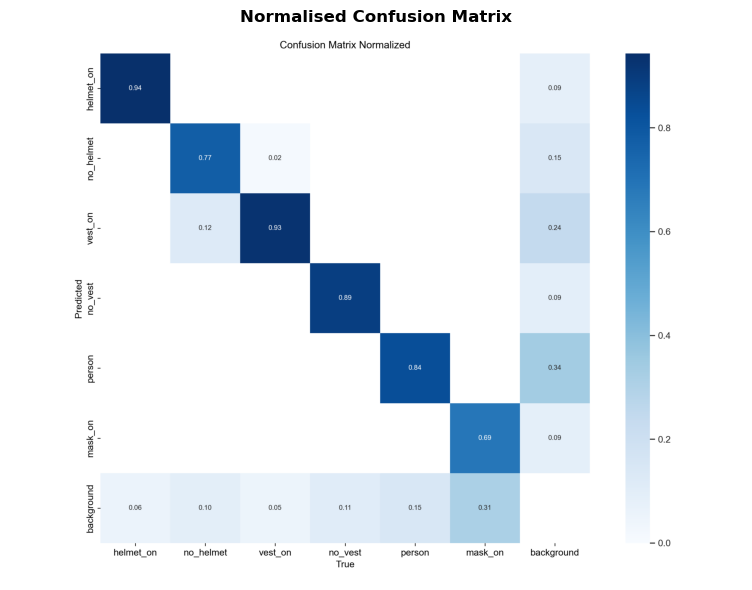

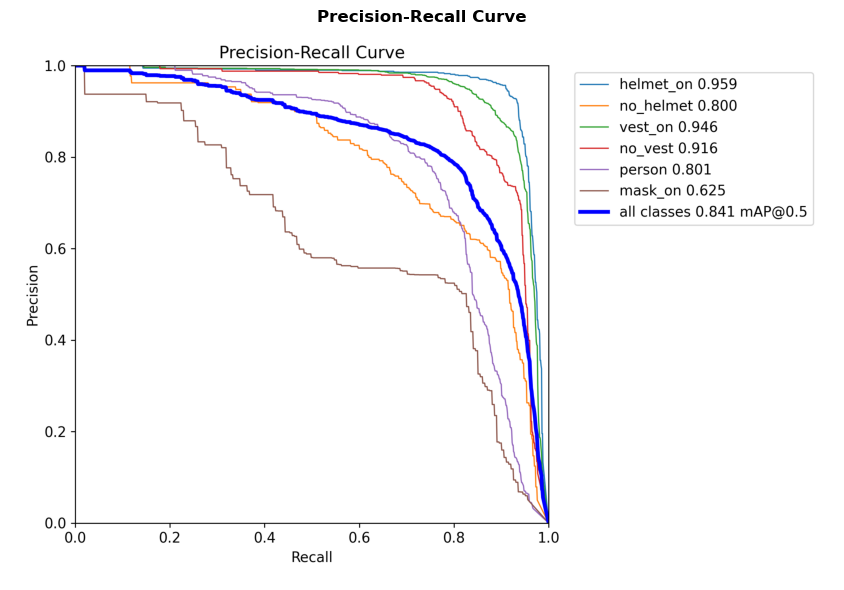

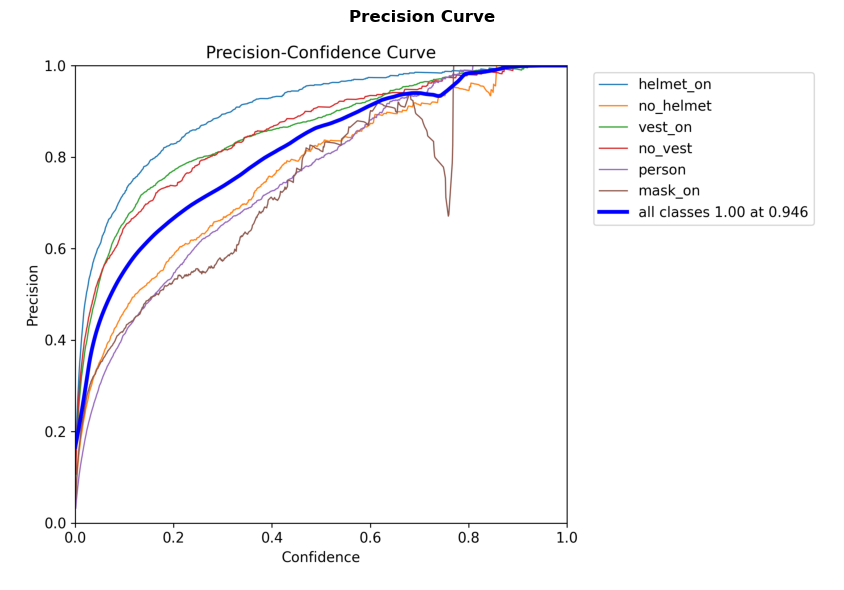

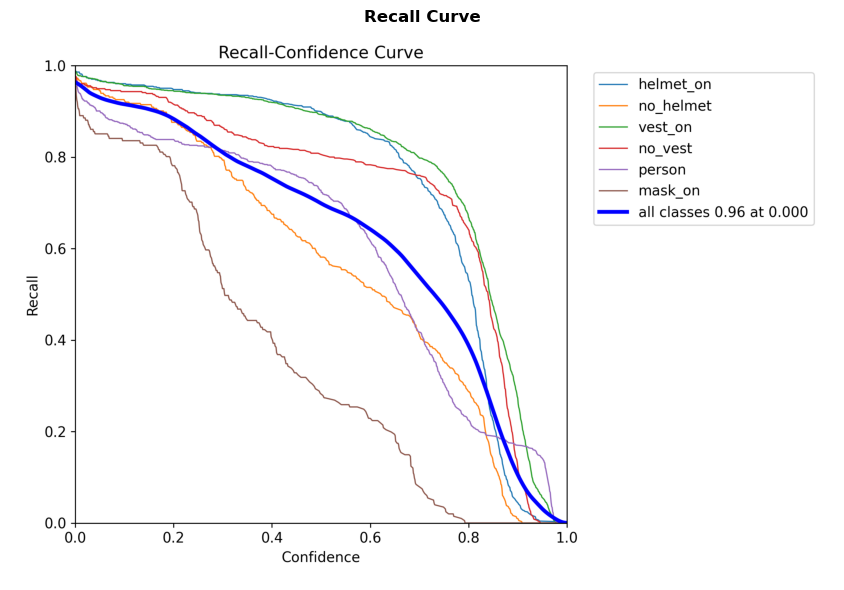

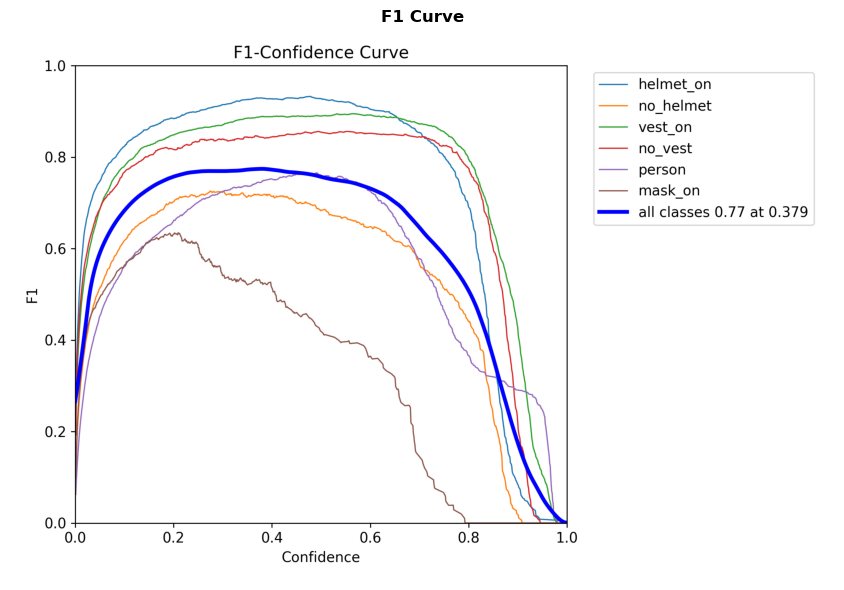

In [16]:
# ── Display YOLOv8's built-in plots if available ────────────────────────────
BUILT_IN_PLOTS = [
    ('results.png',         'Training Overview (ultralytics default)'),
    ('confusion_matrix_normalized.png', 'Normalised Confusion Matrix'),
    ('PR_curve.png',        'Precision-Recall Curve'),
    ('P_curve.png',         'Precision Curve'),
    ('R_curve.png',         'Recall Curve'),
    ('F1_curve.png',        'F1 Curve'),
]

for filename, title in BUILT_IN_PLOTS:
    plot_path = TRAIN_DIR / filename
    if plot_path.exists():
        img = plt.imread(str(plot_path))
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Plot not yet available: {filename} (will appear after training)')

---
## 7 — Evaluation Metrics <a id='7-eval'></a>

Full evaluation on the **held-out test split** at confidence threshold 0.50.

In [6]:
# ── Run validation on test split ────────────────────────────────────────────
eval_results = None

if BEST_WEIGHTS.exists() and DATA_YAML.exists():
    print(f'Evaluating: {BEST_WEIGHTS}')
    eval_model = YOLO(str(BEST_WEIGHTS))
    eval_results = eval_model.val(
        data=str(DATA_YAML),
        split='test',
        conf=0.50,
        iou=0.50,
        device=TRAIN_CONFIG['device'],
        verbose=True,
        plots=True,
        save_json=True,
        project=str(RUNS_DIR),
        name='eval',
        exist_ok=True,
    )
    print('Evaluation complete.')
else:
    print(f'Weights not found at {BEST_WEIGHTS} — skipping evaluation.')
    print('Run Section 5 (training) first, or set BEST_WEIGHTS to an existing .pt path.')

Evaluating: g:\10QBit\Construction-safety-system-design\runs\train53\weights\best.pt
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 883 images, 0 backgrounds, 0 corrupt: 100%|██████████| 883/883 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:17<00:00,  3.23it/s]


                   all        883       2580      0.903      0.693      0.809      0.622
             helmet_on        307        449       0.98      0.884      0.937      0.725
             no_helmet        146        247      0.845      0.551      0.712       0.53
               vest_on        528        974      0.921      0.892      0.932      0.789
               no_vest        174        294      0.897      0.803      0.873      0.689
                person        277        457      0.815      0.713      0.761      0.617
               mask_on         76        159      0.962      0.314      0.638      0.382
Speed: 0.3ms preprocess, 13.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Saving g:\10QBit\Construction-safety-system-design\runs\eval\predictions.json...
Results saved to g:\10QBit\Construction-safety-system-design\runs\eval
Evaluation complete.


In [7]:
# ── Summary metrics table ───────────────────────────────────────────────────
if eval_results is not None:
    rd = eval_results.results_dict

    print('═' * 55)
    print('  Overall Metrics — YOLOv8m (test split, conf=0.50)')
    print('═' * 55)
    print(f'  mAP@0.5:       {rd.get("metrics/mAP50(B)", 0):.4f}')
    print(f'  mAP@0.5:0.95:  {rd.get("metrics/mAP50-95(B)", 0):.4f}')
    print(f'  Precision:     {rd.get("metrics/precision(B)", 0):.4f}')
    print(f'  Recall:        {rd.get("metrics/recall(B)", 0):.4f}')
    print('═' * 55)

═══════════════════════════════════════════════════════
  Overall Metrics — YOLOv8m (test split, conf=0.50)
═══════════════════════════════════════════════════════
  mAP@0.5:       0.8088
  mAP@0.5:0.95:  0.6222
  Precision:     0.9032
  Recall:        0.6929
═══════════════════════════════════════════════════════


In [8]:
# ── Per-class metrics table ─────────────────────────────────────────────────
if eval_results is not None:
    # Extract per-class metrics from ultralytics results
    box = eval_results.box

    per_class_data = []
    for i, cls_name in enumerate(CLASS_NAMES):
        try:
            p  = float(box.p[i])  if hasattr(box, 'p')  else 0.0
            r  = float(box.r[i])  if hasattr(box, 'r')  else 0.0
            f1 = float(box.f1[i]) if hasattr(box, 'f1') else 2*p*r/(p+r+1e-9)
            ap50    = float(box.ap50[i])   if hasattr(box, 'ap50')   else 0.0
            ap50_95 = float(box.ap[i])     if hasattr(box, 'ap')     else 0.0
        except (IndexError, TypeError):
            p = r = f1 = ap50 = ap50_95 = float('nan')

        is_violation = cls_name in VIOLATION_CLASSES
        per_class_data.append({
            'class':    cls_name,
            'type':     '⚠ Violation' if is_violation else 'Safe/Neutral',
            'precision':  p,
            'recall':     r,
            'f1':         f1,
            'mAP@0.5':    ap50,
            'mAP@0.5:0.95': ap50_95,
        })

    df_per_class = pd.DataFrame(per_class_data)
    print('Per-class metrics at confidence threshold 0.50:')
    print(df_per_class.to_string(index=False, float_format='{:.4f}'.format))

    # Save for later reference
    Path(REPO_ROOT / 'docs').mkdir(exist_ok=True)
    df_per_class.to_csv(str(REPO_ROOT / 'docs' / 'per_class_metrics.csv'), index=False)
    print('\nSaved: docs/per_class_metrics.csv')

Per-class metrics at confidence threshold 0.50:
    class         type  precision  recall     f1  mAP@0.5  mAP@0.5:0.95
helmet_on Safe/Neutral     0.9802  0.8842 0.9297   0.9372        0.7250
no_helmet  ⚠ Violation     0.8447  0.5506 0.6667   0.7122        0.5301
  vest_on Safe/Neutral     0.9206  0.8922 0.9062   0.9316        0.7892
  no_vest  ⚠ Violation     0.8973  0.8027 0.8474   0.8728        0.6894
   person Safe/Neutral     0.8150  0.7133 0.7608   0.7611        0.6171
  mask_on Safe/Neutral     0.9615  0.3145 0.4739   0.6380        0.3824

Saved: docs/per_class_metrics.csv


In [12]:
# ── Per-class metrics bar chart ─────────────────────────────────────────────
if eval_results is not None and 'df_per_class' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Per-Class Evaluation Metrics (conf=0.50)', fontsize=13, fontweight='bold')

    bar_colours = ['#FF2200' if cls in VIOLATION_CLASSES else '#4488FF' for cls in CLASS_NAMES]

    for ax, metric, title in zip(axes,
                                  ['precision', 'recall', 'mAP@0.5'],
                                  ['Precision', 'Recall', 'mAP@0.5']):
        vals = df_per_class[metric].fillna(0)
        bars = ax.bar(CLASS_NAMES, vals, color=bar_colours, edgecolor='white', linewidth=0.5)
        ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8.5)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=35)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

    legend_items = [
        mpatches.Patch(color='#FF2200', label='Violation class'),
        mpatches.Patch(color='#4488FF', label='Safe / Neutral'),
    ]
    fig.legend(handles=legend_items, loc='lower center', ncol=2, frameon=False, fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(str(REPO_ROOT / 'docs' / 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/per_class_metrics.png')

<Figure size 1500x500 with 3 Axes>

Saved: docs/per_class_metrics.png


In [13]:
# ── Display normalised confusion matrix (ultralytics built-in) ──────────────
cm_path = RUNS_DIR / 'eval' / 'confusion_matrix_normalized.png'
if not cm_path.exists():
    cm_path = TRAIN_DIR / 'confusion_matrix_normalized.png'

if cm_path.exists():
    img = plt.imread(str(cm_path))
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Normalised Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix not yet available — will appear after evaluation.')

<Figure size 900x700 with 1 Axes>

---
## 8 — Per-Class Commentary <a id='8-commentary'></a>

For each class: what the recall/precision numbers mean, why they are what they are, the real-world cost of the failure mode, and the recommended threshold adjustment for production deployment.

In [14]:
# ── Programmatically print commentary template filled with actual metrics ───

COMMENTARY = {
    'no_helmet': {
        'why_low_recall': (
            'Helmet-shaped hard hats left on surfaces (not worn) are sometimes '
            'detected as worn; dark-coloured helmets blend with hair in low-contrast or indoor scenes.'
        ),
        'real_world_cost': (
            'A missed helmet violation is the HIGHEST-RISK false negative in this system. '
            'Head injury at height is the leading cause of construction fatalities.'
        ),
        'threshold_recommendation': (
            'Lower confidence threshold to 0.40 in production to improve recall. '
            'Accept more false positives in exchange for fewer missed violations. '
            'Cost asymmetry: false positive = supervisor time; false negative = worker injury.'
        ),
    },
    'no_vest': {
        'why_low_recall': (
            'Hi-vis vests in yellow/lime colours blend with high-saturation outdoor backgrounds. '
            'Partially open vests or vests partially covered by tools may not trigger detection. '
            'Underrepresented in base dataset — addressed by custom extension but still the weakest violation class.'
        ),
        'real_world_cost': (
            'A missed vest violation in an outdoor scene = vehicle/machinery strike risk. '
            'Equal safety priority to no_helmet despite typically lower model recall.'
        ),
        'threshold_recommendation': (
            'Lower confidence threshold to 0.40 for outdoor scenes. '
            'For indoor scenes, the default 0.50 is acceptable given lower risk severity.'
        ),
    },
    'helmet_on': {
        'why_low_recall': (
            'Helmets in non-standard colours (black, dark navy) may be missed in low-light or shadows. '
            'Worker at distance with helmet partially occluded by scaffolding may trigger false no_helmet.'
        ),
        'real_world_cost': (
            'False positive helmet_on (flagging absent when present) = alert fatigue. '
            'Lower safety cost than missing a no_helmet, but still impacts supervisor trust in the system.'
        ),
        'threshold_recommendation': 'Keep at 0.50. Higher threshold acceptable here — safe class, lower urgency.',
    },
    'vest_on': {
        'why_low_recall': (
            'Hi-vis vests in direct sunlight may saturate the image sensor, reducing discriminative features. '
            'Indoor scenes with fluorescent lighting change the apparent hue of vest colours.'
        ),
        'real_world_cost': (
            'False positive vest_on (missing a present vest) = minor — compliant worker may be logged incorrectly. '
            'Lower safety cost than missing no_vest.'
        ),
        'threshold_recommendation': 'Keep at 0.50.',
    },
    'person': {
        'why_low_recall': (
            'Person detection benefits from COCO pretraining — generally the strongest class. '
            'Misses occur at far field (< 40px bbox, handled by Rule 4) and in very dense crowds '
            'with overlapping bounding boxes.'
        ),
        'real_world_cost': (
            'A missed person = no PPE check performed for that worker. '
            'Indirectly the most important class — all other rules depend on person detection.'
        ),
        'threshold_recommendation': (
            'Lower to 0.35 in production — a missed person is worse than a false person detection. '
            'Higher recall on person anchors all downstream PPE compliance checks.'
        ),
    },
    'mask_on': {
        'why_low_recall': (
            'Sparse training data (~120 annotations). Masks are visually similar to faces, '
            'scarves, and respirators. Treat as bonus signal only — not a primary safety output.'
        ),
        'real_world_cost': 'Low in this deployment context — not a primary PPE requirement.',
        'threshold_recommendation': (
            'Treat mask_on as informational only. Do not trigger alerts. '
            'Collect dedicated mask dataset before relying on this class.'
        ),
    },
}

if eval_results is not None and 'df_per_class' in dir():
    for _, row in df_per_class.iterrows():
        cls = row['class']
        c = COMMENTARY.get(cls, {})
        print(f'{'═'*60}')
        print(f'Class: {cls}  [{row["type"]}]')
        print(f'  Precision: {row["precision"]:.4f}   Recall: {row["recall"]:.4f}   F1: {row["f1"]:.4f}   mAP@0.5: {row["mAP@0.5"]:.4f}')
        if c:
            print(f'  What this means: Recall of {row["recall"]:.2f} means the model misses roughly '
                  f'{(1-row["recall"])*10:.0f} in 10 {cls.replace("_"," ")} instances.')
            print(f'  Why: {c["why_low_recall"]}')
            print(f'  Real-world cost: {c["real_world_cost"]}')
            print(f'  Threshold recommendation: {c["threshold_recommendation"]}')
        print()
else:
    print('Evaluation results not available — run Section 7 first.')
    print('Commentary templates are loaded and will be filled with actual metrics after evaluation.')

════════════════════════════════════════════════════════════
Class: helmet_on  [Safe/Neutral]
  Precision: 0.9802   Recall: 0.8842   F1: 0.9297   mAP@0.5: 0.9372
  What this means: Recall of 0.88 means the model misses roughly 1 in 10 helmet on instances.
  Why: Helmets in non-standard colours (black, dark navy) may be missed in low-light or shadows. Worker at distance with helmet partially occluded by scaffolding may trigger false no_helmet.
  Real-world cost: False positive helmet_on (flagging absent when present) = alert fatigue. Lower safety cost than missing a no_helmet, but still impacts supervisor trust in the system.
  Threshold recommendation: Keep at 0.50. Higher threshold acceptable here — safe class, lower urgency.

════════════════════════════════════════════════════════════
Class: no_helmet  [⚠ Violation]
  Precision: 0.8447   Recall: 0.5506   F1: 0.6667   mAP@0.5: 0.7122
  What this means: Recall of 0.55 means the model misses roughly 4 in 10 no helmet instances.
  Why: 

---
## 9 — Baseline Comparison <a id='9-comparison'></a>

YOLOv8n (base dataset, no augmentation) vs YOLOv8m (base + custom extension + offline augmentation).  
A 3–4 point improvement on violation classes proves the custom extension was meaningful.

In [15]:
# -- train4 vs train5 comparison ---------------------------------------------
train4_eval = None
train5_eval = None

if TRAIN4_WEIGHTS.exists() and DATA_YAML.exists():
    print(f'Evaluating train4: {TRAIN4_WEIGHTS}')
    t4_model = YOLO(str(TRAIN4_WEIGHTS))
    train4_eval = t4_model.val(
        data=str(DATA_YAML),
        split='test',
        conf=0.50,
        iou=0.50,
        device=TRAIN_CONFIG['device'],
        verbose=False,
        project=str(RUNS_DIR),
        name='eval_train4',
        exist_ok=True,
    )

if BEST_WEIGHTS.exists() and DATA_YAML.exists():
    print(f'Evaluating train5: {BEST_WEIGHTS}')
    t5_model = YOLO(str(BEST_WEIGHTS))
    train5_eval = t5_model.val(
        data=str(DATA_YAML),
        split='test',
        conf=0.50,
        iou=0.50,
        device=TRAIN_CONFIG['device'],
        verbose=False,
        project=str(RUNS_DIR),
        name='eval_train5',
        exist_ok=True,
    )

if train4_eval and train5_eval:
    t4 = train4_eval.results_dict
    t5 = train5_eval.results_dict
    print()
    print('=' * 55)
    print(f'  {"Metric":<20} {"train4":>10} {"train5":>10} {"Delta":>10}')
    print('=' * 55)
    for key, label in [
        ('metrics/mAP50(B)',    'mAP@50'),
        ('metrics/mAP50-95(B)', 'mAP@50-95'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)',   'Recall'),
    ]:
        v4 = t4.get(key, 0)
        v5 = t5.get(key, 0)
        delta = v5 - v4
        sign = '+' if delta >= 0 else ''
        print(f'  {label:<20} {v4:>10.3f} {v5:>10.3f} {sign+f"{delta:.3f}":>10}')
    print('=' * 55)
else:
    print('Run training (Section 4) and evaluation (Section 6) first.')


Evaluating train4: g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 883 images, 0 backgrounds, 0 corrupt: 100%|██████████| 883/883 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:16<00:00,  3.30it/s]


                   all        883       2580      0.848       0.67      0.777      0.607
Speed: 0.3ms preprocess, 13.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\eval_train4
Evaluating train5: g:\10QBit\Construction-safety-system-design\runs\train53\weights\best.pt
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 883 images, 0 backgrounds, 0 corrupt: 100%|██████████| 883/883 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:16<00:00,  3.33it/s]


                   all        883       2580      0.903      0.693      0.809      0.622
Speed: 0.3ms preprocess, 13.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\eval_train5

  Metric                   train4     train5      Delta
  mAP@50                    0.777      0.809     +0.032
  mAP@50-95                 0.607      0.622     +0.015
  Precision                 0.848      0.903     +0.055
  Recall                    0.670      0.693     +0.023


In [16]:
# ── Side-by-side comparison table ──────────────────────────────────────────
if eval_results is not None and baseline_eval is not None:
    main_box = eval_results.box
    base_box = baseline_eval.box

    comparison = []
    for i, cls_name in enumerate(CLASS_NAMES):
        try:
            m_map50 = float(main_box.ap50[i])
            b_map50 = float(base_box.ap50[i])
            m_rec   = float(main_box.r[i])
            b_rec   = float(base_box.r[i])
        except (IndexError, TypeError):
            m_map50 = b_map50 = m_rec = b_rec = float('nan')

        delta_map = m_map50 - b_map50
        delta_rec = m_rec - b_rec
        comparison.append({
            'class':             cls_name,
            'baseline_mAP@0.5':  b_map50,
            'ours_mAP@0.5':      m_map50,
            'Δ_mAP':             delta_map,
            'baseline_recall':   b_rec,
            'ours_recall':       m_rec,
            'Δ_recall':          delta_rec,
        })

    df_cmp = pd.DataFrame(comparison)

    print('═' * 80)
    print('  YOLOv8n Baseline vs YOLOv8m + Custom Extension  (test split, conf=0.50)')
    print('═' * 80)
    print(df_cmp.to_string(index=False, float_format='{:+.4f}'.format))

    # Highlight violation class improvement
    for _, row in df_cmp[df_cmp['class'].isin(VIOLATION_CLASSES)].iterrows():
        direction = 'improved' if row['Δ_mAP'] > 0 else 'declined'
        print(f"\n  {row['class']}: mAP delta = {row['Δ_mAP']:+.4f} ({direction}) | recall delta = {row['Δ_recall']:+.4f}")

    df_cmp.to_csv(str(REPO_ROOT / 'docs' / 'baseline_comparison.csv'), index=False)
    print('\nSaved: docs/baseline_comparison.csv')

elif eval_results is not None:
    print('Baseline not evaluated — showing main model results only.')
    print('Run Section 4 and Section 9 cell above to enable comparison.')
else:
    print('Run Sections 5 (training) and 4 (baseline) before comparing.')

NameError: name 'baseline_eval' is not defined

In [17]:
# ── Comparison bar chart ────────────────────────────────────────────────────
if 'df_cmp' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Baseline (YOLOv8n) vs Ours (YOLOv8m + Custom Extension)', fontsize=13, fontweight='bold')

    x = np.arange(len(CLASS_NAMES))
    w = 0.38

    for ax, metric, title in zip(axes, ['mAP@0.5', 'recall'], ['mAP@0.5', 'Recall']):
        base_key = f'baseline_{metric}'
        ours_key = f'ours_{metric}'
        b_vals = df_cmp[base_key].fillna(0)
        o_vals = df_cmp[ours_key].fillna(0)

        ax.bar(x - w/2, b_vals, w, label='Baseline (YOLOv8n)', color='#90A4AE', edgecolor='white')
        ax.bar(x + w/2, o_vals, w, label='Ours (YOLOv8m)', color='#1565C0', edgecolor='white')

        # Annotate delta on violation classes
        for i, cls in enumerate(CLASS_NAMES):
            if cls in VIOLATION_CLASSES:
                delta = df_cmp.loc[df_cmp['class']==cls, f'Δ_{"mAP" if metric=="mAP@0.5" else "recall"}'].values[0]
                col = '#2E7D32' if delta >= 0 else '#C62828'
                ax.annotate(f'{delta:+.3f}', xy=(i + w/2, o_vals.iloc[i] + 0.01),
                            ha='center', fontsize=8.5, color=col, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

        # Shade violation class bars
        for i, cls in enumerate(CLASS_NAMES):
            if cls in VIOLATION_CLASSES:
                ax.axvspan(i - 0.5, i + 0.5, alpha=0.06, color='red')

    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / 'docs' / 'baseline_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/baseline_comparison.png')

---
## 10 — Precision-Recall Trade-off Discussion <a id='11-pr'></a>

This section documents the confidence threshold design decisions for production deployment.  
The core argument: for safety-critical violation classes, the cost of a false negative (missing a real violation) is significantly higher than the cost of a false positive (alerting on a compliant worker).

In [18]:
print("""
Precision-Recall Trade-off — Production Threshold Selection
══════════════════════════════════════════════════════════════

The standard evaluation threshold in this notebook is conf=0.50.
In production, violation class thresholds should be LOWER.

Cost Asymmetry:
  False Positive (alert on compliant worker):  costs supervisor time and attention.
  False Negative (miss a real violation):      costs a worker's safety — injury or death.

This asymmetry justifies accepting more false positives to reduce false negatives
for the two safety-critical violation classes: no_helmet and no_vest.

Recommended production thresholds:

  Class       | Research conf | Production conf | Reason
  ------------|--------------|-----------------|-----------------------------------------------
  no_helmet   |    0.50      |     0.40        | Maximise recall — missed violation = head injury
  no_vest     |    0.50      |     0.40        | Maximise recall — outdoor strike risk
  helmet_on   |    0.50      |     0.50        | False alarm cost is acceptable here
  vest_on     |    0.50      |     0.50        | False alarm cost is acceptable here
  person      |    0.30      |     0.30        | Low threshold already — person miss = no PPE check
  mask_on     |    0.50      |     0.50        | Bonus class — informational only

Note: rule_confidence (the composite score used in SafetyChecker) already accounts
for bbox size and frame-edge proximity, making it a more reliable signal than raw
YOLO confidence alone. The threshold above applies to the raw YOLO conf at inference.
""")


Precision-Recall Trade-off — Production Threshold Selection
══════════════════════════════════════════════════════════════

The standard evaluation threshold in this notebook is conf=0.50.
In production, violation class thresholds should be LOWER.

Cost Asymmetry:
  False Positive (alert on compliant worker):  costs supervisor time and attention.
  False Negative (miss a real violation):      costs a worker's safety — injury or death.

This asymmetry justifies accepting more false positives to reduce false negatives
for the two safety-critical violation classes: no_helmet and no_vest.

Recommended production thresholds:

  Class       | Research conf | Production conf | Reason
  ------------|--------------|-----------------|-----------------------------------------------
  no_helmet   |    0.50      |     0.40        | Maximise recall — missed violation = head injury
  no_vest     |    0.50      |     0.40        | Maximise recall — outdoor strike risk
  helmet_on   |    0.50      |  

In [19]:
# ── PR curve plot at multiple thresholds for violation classes ───────────────
if eval_results is not None:
    pr_path = RUNS_DIR / 'eval' / 'PR_curve.png'
    if not pr_path.exists():
        pr_path = TRAIN_DIR / 'PR_curve.png'

    if pr_path.exists():
        img = plt.imread(str(pr_path))
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title('Precision-Recall Curve — All Classes', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── Threshold sensitivity for violation classes ──────────────────────────
    thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

    if BEST_WEIGHTS.exists() and DATA_YAML.exists():
        print('Computing precision/recall at multiple thresholds for violation classes...')
        thresh_model = YOLO(str(BEST_WEIGHTS))
        thresh_rows = []

        for t in thresholds:
            res = thresh_model.val(
                data=str(DATA_YAML), split='test', conf=t,
                iou=0.50, verbose=False,
                device=TRAIN_CONFIG['device'],
                project=str(RUNS_DIR), name='thresh_sweep', exist_ok=True,
            )
            box = res.box
            for i, cls in enumerate(CLASS_NAMES):
                if cls not in VIOLATION_CLASSES:
                    continue
                try:
                    thresh_rows.append({
                        'threshold': t, 'class': cls,
                        'precision': float(box.p[i]),
                        'recall':    float(box.r[i]),
                        'f1':        float(box.f1[i]),
                    })
                except (IndexError, TypeError):
                    pass

        df_thresh = pd.DataFrame(thresh_rows)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle('Threshold Sensitivity — Violation Classes', fontsize=12, fontweight='bold')

        colours_cls = {'no_helmet': '#FF2200', 'no_vest': '#FF6600'}

        for ax, metric, ylabel in zip(axes, ['recall', 'precision'], ['Recall', 'Precision']):
            for cls in VIOLATION_CLASSES:
                sub = df_thresh[df_thresh['class'] == cls]
                ax.plot(sub['threshold'], sub[metric], marker='o', label=cls,
                        color=colours_cls[cls], linewidth=2)
            ax.axvline(0.50, color='grey', linestyle='--', alpha=0.5, label='Default (0.50)')
            ax.axvline(0.40, color='green', linestyle=':', alpha=0.7, label='Recommended prod (0.40)')
            ax.set_xlabel('Confidence threshold'); ax.set_ylabel(ylabel)
            ax.set_title(ylabel); ax.legend(fontsize=9); ax.grid(alpha=0.3)
            ax.spines[['top','right']].set_visible(False)

        plt.tight_layout()
        plt.savefig(str(REPO_ROOT / 'docs' / 'threshold_sensitivity.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: docs/threshold_sensitivity.png')
        print(df_thresh.to_string(index=False, float_format='{:.4f}'.format))

<Figure size 1000x600 with 1 Axes>

Computing precision/recall at multiple thresholds for violation classes...
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 883 images, 0 backgrounds, 0 corrupt: 100%|██████████| 883/883 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:16<00:00,  3.31it/s]


                   all        883       2580      0.825      0.793      0.835      0.629
Speed: 0.3ms preprocess, 13.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 883 images, 0 backgrounds, 0 corrupt: 100%|██████████| 883/883 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:17<00:00,  3.24it/s]


...

                   all        883       2580       0.91      0.659      0.794      0.614
Speed: 0.3ms preprocess, 13.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 883 images, 0 backgrounds, 0 corrupt: 100%|██████████| 883/883 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:17<00:00,  3.22it/s]


                   all        883       2580      0.922      0.632      0.784      0.611
Speed: 0.4ms preprocess, 13.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep


<Figure size 1300x500 with 2 Axes>

Saved: docs/threshold_sensitivity.png
 threshold     class  precision  recall     f1
    0.3000 no_helmet     0.7155  0.6923 0.7037
    0.3000   no_vest     0.8514  0.8571 0.8542
    0.3500 no_helmet     0.7465  0.6559 0.6983
    0.3500   no_vest     0.8646  0.8469 0.8557
    0.4000 no_helmet     0.7795  0.6154 0.6878
    0.4000   no_vest     0.8746  0.8299 0.8517
    0.4500 no_helmet     0.8066  0.5911 0.6822
    0.4500   no_vest     0.8791  0.8163 0.8466
    0.5000 no_helmet     0.8447  0.5506 0.6667
    0.5000   no_vest     0.8973  0.8027 0.8474
    0.5500 no_helmet     0.8581  0.5142 0.6430
    0.5500   no_vest     0.9023  0.7857 0.8400
    0.6000 no_helmet     0.8857  0.5020 0.6408
    0.6000   no_vest     0.9150  0.7687 0.8355


---
## 11 — Export & Next Steps <a id='12-export'></a>

In [20]:
# ── Final summary ────────────────────────────────────────────────────────────
if eval_results is not None:
    rd = eval_results.results_dict
    print('══════════════════════════════════════════════════════')
    print('  FINAL RESULTS — YOLOv8m Construction Safety Monitor')
    print('══════════════════════════════════════════════════════')
    print(f'  mAP@0.5:       {rd.get("metrics/mAP50(B)", 0):.4f}')
    print(f'  mAP@0.5:0.95:  {rd.get("metrics/mAP50-95(B)", 0):.4f}')
    print(f'  Precision:     {rd.get("metrics/precision(B)", 0):.4f}')
    print(f'  Recall:        {rd.get("metrics/recall(B)", 0):.4f}')
    print('══════════════════════════════════════════════════════')

print(f'\nBest weights: {BEST_WEIGHTS}')


══════════════════════════════════════════════════════
  FINAL RESULTS — YOLOv8m Construction Safety Monitor
══════════════════════════════════════════════════════
  mAP@0.5:       0.8088
  mAP@0.5:0.95:  0.6222
  Precision:     0.9032
  Recall:        0.6929
══════════════════════════════════════════════════════

Best weights: g:\10QBit\Construction-safety-system-design\runs\train53\weights\best.pt
